In [1]:
import sys
sys.path.insert(0,'..')

import oqupy as oqupy
import numpy as np
import matplotlib.pyplot as plt


In [14]:
omega_cutoff = 5
alpha = 0.1
temperature = 5

def j(x):
    return 2*alpha*x

# compute the process tensor with the counting field value u=0.1

correlations=oqupy.bath_correlations.CountingCustomSD(j,cutoff=omega_cutoff,countingfield=0.1,
                                                 cutoff_type='exponential',temperature=temperature)



correlationsnocf=oqupy.bath_correlations.CountingCustomSD(j,cutoff=omega_cutoff,countingfield=0.0,
                                                 cutoff_type='exponential',temperature=temperature)


bath=oqupy.Bath(oqupy.operators.sigma("z")/2.0, correlations)
bathnocf=oqupy.Bath(oqupy.operators.sigma("z")/2.0, correlationsnocf)

pt_tempo_parameters = oqupy.TempoParameters(dt=0.1, dkmax=20, epsrel=10**(-4))

ptt=oqupy.pt_tempo.PtTempoCounting(bath,0.0,2.0,parameters=pt_tempo_parameters)
pttnocf=oqupy.pt_tempo.PtTempoCounting(bathnocf,0.0,2.0,parameters=pt_tempo_parameters)
ptt.compute()
pttnocf.compute()



--> PT-TEMPO computation:
100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.2s
--> PT-TEMPO computation:
100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.2s


In [15]:

initial_state=oqupy.operators.spin_dm("z-")

def hamiltonian_t(t): 
    return oqupy.operators.sigma("x")/2.0

# evaluate the dynamics at that counting field

system = oqupy.TimeDependentSystem(hamiltonian_t)

proctens=ptt.get_process_tensor()
proctensnocf=pttnocf.get_process_tensor()
dynamics = oqupy.compute_dynamics(system=system, initial_state=initial_state,process_tensor=proctens)
dynamicsnocf = oqupy.compute_dynamics(system=system, initial_state=initial_state,process_tensor=proctensnocf)


--> Compute dynamics:
100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.4s
--> Compute dynamics:
100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.4s


/Users/paul/OQuPy/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/paul/OQuPy/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


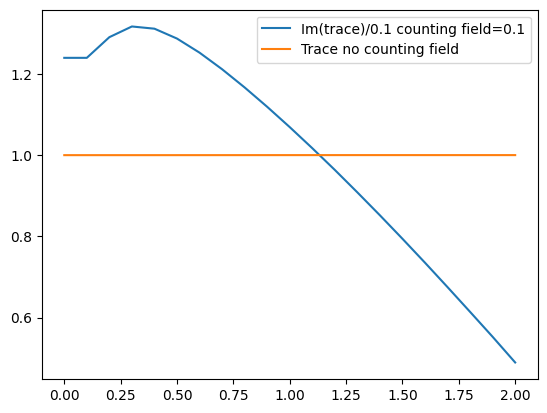

In [16]:
# this should be the mean heat transfer to/from the bath, evaluated at counting field 0.1
plt.plot(dynamics.times,dynamics.states.trace(axis1=1,axis2=2).imag/0.1,label='Im(trace)/0.1 counting field=0.1')
# trace of the density matrix when u=0.0 for comparison
plt.plot(dynamics.times,dynamicsnocf.states.trace(axis1=1,axis2=2),label='Trace no counting field')
plt.legend()

In [19]:
finalq=(dynamics.states.trace(axis1=1,axis2=2).imag/0.1)[-1] # compute the heat at the end of the PT

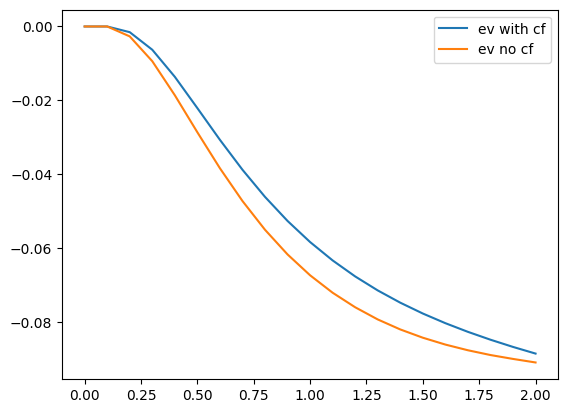

In [5]:
# look at expectation values, after running the above with u=0.0 and 0.1 
# (the u=0.1 case is not a real expectation value but just to see)

plt.plot(dynamics.times,list(map(lambda x: np.matmul(x,oqupy.operators.sigma("x")).trace(),dynamics.states)),label='ev with cf')

plt.plot(dynamics.times,list(map(lambda x: np.matmul(x,oqupy.operators.sigma("x")).trace(),dynamicsnocf.states)),label='ev no cf')

plt.legend()

In [21]:
# let's try the tempo version, first the normal dynamics
# the quantities bath and bathnocf are set up above

tsystem = oqupy.System(0.5 * oqupy.operators.sigma("x"))
trun=oqupy.Tempo(tsystem,bathnocf,parameters=pt_tempo_parameters,initial_state=initial_state,start_time=0.0)

In [22]:
dynamics=trun.compute(end_time=2.0)

--> TEMPO computation:
100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.2s


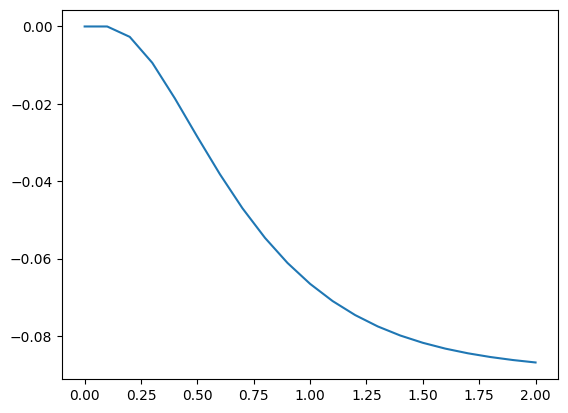

In [23]:
t, s_x = dynamics.expectations(oqupy.operators.sigma("x"), real=True)

plt.plot(t, s_x, label=r'$\alpha=0.3$')

In [24]:
truncf=oqupy.tempo.TempoCounting(tsystem,bath,parameters=pt_tempo_parameters,initial_state=initial_state,start_time=0.0)

In [25]:
dynamicscf=truncf.compute(end_time=2.0)

--> TEMPO computation:
100.0%   20 of   20 [########################################] 00:00:00
Elapsed time: 0.3s


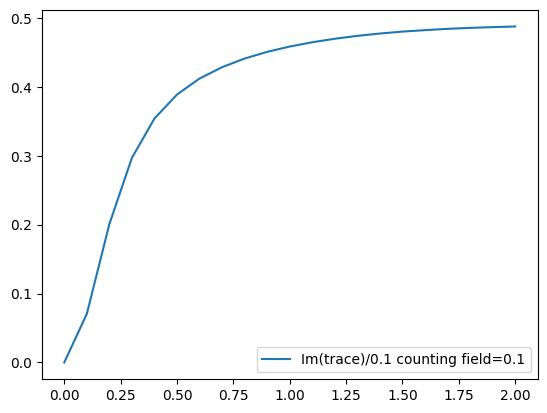

In [26]:
#  extract the heat from the tempo simulatio with u=0.1
plt.plot(dynamicscf.times,dynamicscf.states.trace(axis1=1,axis2=2).imag/0.1,label='Im(trace)/0.1 counting field=0.1')
plt.legend()

In [27]:
finalqtempo=dynamicscf.states.trace(axis1=1,axis2=2).imag/0.1

In [30]:
finalqtempo[-1]

0.4874886847506213

In [31]:
finalq

0.4894559946300412

In [ ]:
# ok so the two codes seemingly agree